# Base models on embeddings of `CLS` token

In [143]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from rital_nlp_project.common.utils import load_clean_data, load_pres
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents

from rital_nlp_project.presidents.models import SmoothedProbaClassifier, smooth_gauss
from rital_nlp_project.presidents.models_utils import *
from rital_nlp_project.presidents.utils import load_with_numbers

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
texts_movies, classes_movies = load_clean_data("../Dataset/clean/movies_clean_bert.parquet")
embeds = np.load("../Dataset/embeddings/movies_bigbird_base.npy") 

In [ ]:
model=LogisticRegression(max_iter=1000)
results = eval_pipeline_movies(model, embeds, classes_movies, cv=True, split=True, clf_report=False)

model=LinearSVC(max_iter=1000)
results = eval_pipeline_movies(model, embeds, classes_movies, cv=True, split=True, clf_report=False)

### Presidents

In [ ]:
texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean_bert.parquet")
X_train = np.load("../Dataset/embeddings/pres_camembert_large.npy") 
df_ids = load_with_numbers("../Dataset/presidents.utf8")
df_ids["class"] = classes_pres
classes_pres = np.where(classes_pres == -1, 1, 0)
y_train = classes_pres

In [155]:
#df_ids.groupby("id")
df_ids.groupby("label")["class"].nunique().value_counts(normalize=True)

class
2    0.681431
1    0.318569
Name: proportion, dtype: float64

In [118]:
df_test = pd.read_parquet("../Dataset/embeddings/presidents_test_metadata_camembert-large.parquet")
ids_test = df_test["label"].to_numpy()
X_test = np.stack(df_test["embedding"].to_numpy())
X_test

array([[ 7.31243864e-02,  1.51087940e-01,  3.43201667e-01, ...,
         1.49358600e-01, -3.60857956e-02, -5.71150854e-02],
       [ 1.13912344e-01,  7.95032755e-02,  1.06489763e-01, ...,
         2.30763331e-01, -1.11681044e-01, -2.23053336e-01],
       [-3.99891675e-01,  2.17171937e-01,  2.26480827e-01, ...,
         1.23760276e-01,  1.25295907e-01, -4.21054065e-02],
       ...,
       [-3.74694653e-02,  1.42264664e-01,  2.46501222e-01, ...,
         1.26727909e-01, -9.98448860e-03, -3.48990798e-01],
       [-3.23684990e-01,  1.78836226e-01,  2.63020515e-01, ...,
         1.74744928e-04,  1.11757651e-01, -8.05989653e-02],
       [ 1.03843741e-01,  1.86888754e-01,  2.88044363e-01, ...,
         3.62314135e-01, -6.97851852e-02, -1.38824865e-01]],
      shape=(27162, 1024))

In [156]:
#X_train, X_test, y_train, y_test = split_fn(embeds, classes_pres)
unique_class, lengths = get_seq_len(y_train)

X_train_extra = add_extra_features(X_train)
X_test_extra = add_extra_features(X_test)

n = 1
X_train_concat = concat_neighbours(X_train, n)
X_test_concat = concat_neighbours(X_test, n)
y_train_concat = y_train[n:-n]
X_train_concat = np.concatenate([X_train_concat, X_train_extra], axis=1)
X_test_concat = np.concatenate([X_test_concat, X_test_extra], axis=1)

model = LogisticRegression(
    max_iter=1000, 
    #class_weight="balanced"
)
model.fit(X_train_concat, y_train_concat)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Extra features 
# X_train_extra = add_extra_features(X_train)
# X_test_extra = add_extra_features(X_test)

# Previous/next phrases concat

# y_test_concat = y_test[n:-n]

# Final X_train/X_test
#X_train_concat = np.concatenate([X_train_concat, X_train_extra], axis=1)
#X_test_concat = np.concatenate([X_test_concat, X_test_extra], axis=1)

# Train baseline model to get P(y|x)


In [79]:
from sklearn.neighbors import KernelDensity

kde_0 = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde_1 = KernelDensity(kernel='gaussian', bandwidth=1.0)
len_0 = lengths[unique_class == 0]
len_1 = lengths[unique_class == 1]

kde_0.fit(len_0.reshape(-1, 1))
kde_1.fit(len_1.reshape(-1, 1))

D_max_0 = len_0.max()
D_max_1 = len_1.max()

In [120]:
classes_pres

array([0, 0, 0, ..., 0, 0, 0], shape=(57413,))

In [80]:
log_probs = np.log(model.predict_proba(X_test[:1000, :]))
D_max = [D_max_0, D_max_1]
kde = [kde_0, kde_1]

S = get_scores_smooth_duration(log_probs, D_max, kde)

ValueError: X has 1024 features, but LogisticRegression is expecting 5122 features as input.

In [ ]:
probas = smooth_gauss(model.predict_proba(X_test_concat), sigma=4)
probas_smooth = smooth_prob_duration(probas, 0.6, S)
pred = probas.argmax(axis=1)

df = pd.DataFrame(data={
    "pred":pred,
    "prob_smooth":probas_smooth[:, 1].ravel(),
    "prob_raw":probas[:, 1]
})

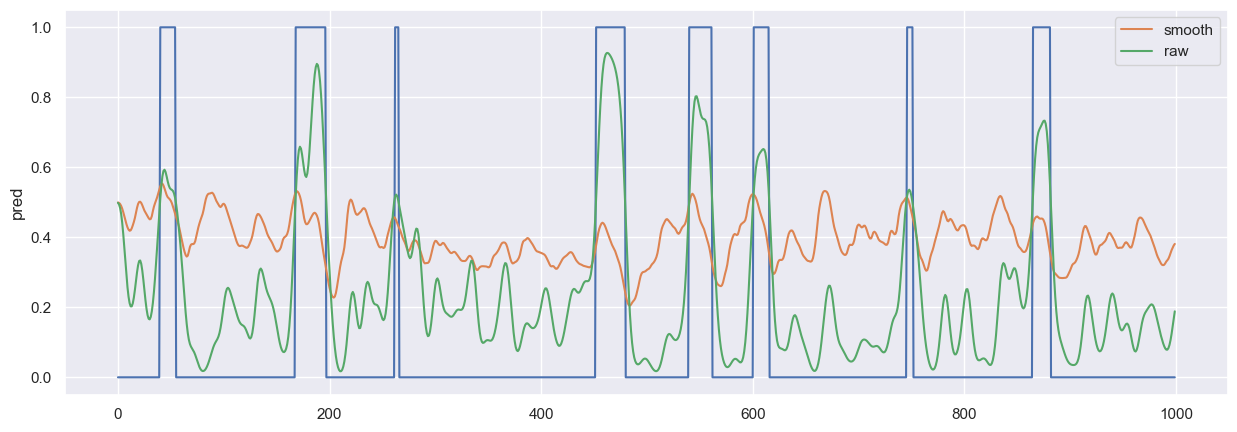

In [ ]:
plt.figure(figsize=(15, 5))

sns.lineplot(df["pred"].iloc[0:1500])
sns.lineplot(df["prob_smooth"].iloc[0:1500], label="smooth")
sns.lineplot(df["prob_raw"].iloc[0:1500], label="raw")
plt.legend()

In [160]:
np.unique(model.predict(X_test_concat), return_counts=True)

(array([0, 1]), array([20809,  6351]))

In [161]:
probas

array([[0.50147052, 0.49852948],
       [0.50593692, 0.49406308],
       [0.51595707, 0.48404293],
       ...,
       [0.92153312, 0.07846688],
       [0.91858835, 0.08141165],
       [0.9171555 , 0.0828445 ]], shape=(27160, 2))

In [ ]:
probs_df = pd.DataFrame(data={"prob":np.pad(probas[:, 1], 1, mode="edge")})
probs_df.to_csv("../Dataset/submissions/submission-pres-1.csv", header=None, index=False)

In [21]:
model.predict(X_train_concat)

array([1, 1, 1, ..., 1, 1, 1], shape=(57411,))

In [22]:
df[["id", "pred"]]["pred"].value_counts()

pred
0    22734
1     4426
Name: count, dtype: int64

In [201]:
lengths = df.groupby("id")["pred"].count().reset_index()
lengths["kde_0"] = kde_0.score_samples(lengths["pred"].to_numpy().reshape(-1, 1))
lengths["kde_1"] = kde_1.score_samples(lengths["pred"].to_numpy().reshape(-1, 1))

df = df.merge(lengths.drop(columns=["pred"]), on="id")

In [192]:
np.exp(df["kde_0"]) + df["prob_raw"]

0        0.630767
1        0.433394
2        0.200027
3        0.085255
4        0.090476
           ...   
27155    0.521757
27156    0.415454
27157    0.411985
27158    0.587709
27159    0.708621
Length: 27160, dtype: float64

In [18]:
df[["id", "mode_label"]].drop_duplicates()

,id,mode_label
0,105,0
13,109,0
75,111,0
219,113,0
278,118,0
...,...,...
26697,552,1
26844,611,1
26912,659,1
26939,729,0


In [128]:
classes_pres

array([1, 1, 1, ..., 1, 1, 1], shape=(57413,))

In [73]:

mods = df.groupby("id")["pred"].agg(lambda x: x.mode().iloc[0])
mods.head(50)

id
4      1
6      0
12     0
13     0
17     0
18     1
21     0
22     1
24     0
27     0
29     0
31     0
33     0
35     0
37     1
38     0
45     0
47     0
48     0
57     0
61     0
67     0
70     0
72     1
76     0
78     0
82     0
91     0
93     0
105    0
109    0
111    0
113    0
118    0
120    1
122    0
123    1
124    0
126    1
129    1
136    0
138    0
141    0
142    1
145    0
152    1
153    0
154    1
157    0
163    1
Name: pred, dtype: int64

In [134]:
pred.head(100)

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
preds = pd.DataFrame(data={"id":train})

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(P_smoothed[0:500][:, 1])
#sns.lineplot(pred_probas[0:500][:, 1])
#sns.lineplot(y_test[0:500])
#sns.lineplot(pred_probas[:500][:, 1])

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(P_smoothed[1000:1500][:, 1])
sns.lineplot(pred_probas[1000:1500][:, 1])
sns.lineplot(y_test[1000:1500])
#sns.lineplot(pred_probas[:500][:, 1])

In [ ]:
pred = smooth_pred(P_smoothed.argmax(axis=1), n=3)

true = y_test_concat
#np.unique(preds, return_counts=True), np.unique(y_test, return_counts=True)
print(accuracy_score(true, pred))
print(f1_score(true, pred, average="macro"))
#print(f1_score(true, path, average="binary"))
print(precision_score(true, pred, average="macro"))
#print(precision_score(true, path, average="binary"))
print(recall_score(true, pred))
print(roc_auc_score(true, P_smoothed[:, 1]))

In [ ]:
pred = smooth_pred(P_smoothed.argmax(axis=1), n=3)

true = y_test_concat
#np.unique(preds, return_counts=True), np.unique(y_test, return_counts=True)
print(accuracy_score(true, pred))
print(f1_score(true, pred, average="macro"))
#print(f1_score(true, path, average="binary"))
print(precision_score(true, pred, average="macro"))
#print(precision_score(true, path, average="binary"))
print(recall_score(true, pred))
print(roc_auc_score(true, P_smoothed[:, 1]))

In [ ]:
pred = smooth_pred(P_smoothed.argmax(axis=1), n=3)
alpha = 0.8
S_final = alpha * log_progs + (1-alpha) * S
P_smoothed = np.exp(S_final - S_final.max(axis=1, keepdims=True))
P_smoothed /= P_smoothed.sum(axis=1, keepdims=True)

#pred = model.predict(X_test_concat)

true = y_test_concat
#np.unique(preds, return_counts=True), np.unique(y_test, return_counts=True)
print(accuracy_score(true, pred))
print(f1_score(true, pred, average="macro"))
#print(f1_score(true, path, average="binary"))
print(precision_score(true, pred, average="macro"))
#print(precision_score(true, path, average="binary"))
print(recall_score(true, pred))
print(roc_auc_score(true, P_smoothed[:, 1]))


In [ ]:
plt.figure(figsize=(15, 5))

pred = smooth_pred(P_smoothed.argmax(axis=1), n=3)

probas = model.predict_proba(X_test_concat)

#sns.lineplot(pred[2000:2700])
#sns.lineplot(P_smoothed[2000:2700, 1])
sns.lineplot(y_test[2000:2700])

### Extra features

In [ ]:
# Cosine similarity 
from sklearn.metrics.pairwise import cosine_distances 

for i in range(len(X_train)-1):
    x1 = X_train[i]
    x2 = X_train[i+1]
    cos_dist = np.dot(x1, x2) / np.linalg.norm(x1) / np.linalg.norm(x2)
    diff = x1 - x2
    sm = x1 + x2

### Concatenation

In [ ]:
n = 1
X_train_concat = concat_neighbours(X_train, n)
X_test_concat = concat_neighbours(X_test, n)
y_train_concat = y_train[n:-n]
y_test_concat = y_test[n:-n]
X_train_concat.shape
#print(X_train.shape, y_train.shape)


In [ ]:
X_train_extra = add_extra_features(X_train)
X_test_extra = add_extra_features(X_test)
# y_train_extra = y_train[1:]
# y_test_extra = y_test[1:]
X_train_concat = np.concatenate([X_train_concat, X_train_extra], axis=1)
X_test_concat = np.concatenate([X_test_concat, X_test_extra], axis=1)
X_train_concat.shape
#X_train_extra.shape, X_train_concat.shape
# model = SmoothedProbaClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"), sigma=1)
# model.fit(X_train_extra, y_train_extra)

In [ ]:
from sklearn.decomposition import TruncatedSVD
lsa = TruncatedSVD()

In [ ]:

model = SmoothedProbaClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"), sigma=1)
model.fit(X_train_concat, y_train_concat)
pred = model.predict(X_test_concat)
true = y_test_concat
for n in range(1, 10):
    path = smooth_pred(pred, passes=1, n=n)
    print(n)
    print(accuracy_score(true, path))
    print(f1_score(true, path, average="macro"))
    #print(f1_score(true, path, average="binary"))
    print(precision_score(true, path, average="macro"))
    #print(precision_score(true, path, average="binary"))
    print(recall_score(true, path))
    print(roc_auc_score(true, pred))
    print()

In [ ]:
pred = model.predict(X_test_concat)

pred = smooth_pred(pred, 1, 3)
print(accuracy_score(true, path))
print(f1_score(true, path, average="macro"))
#print(f1_score(true, path, average="binary"))
print(precision_score(true, path, average="macro"))
#print(precision_score(true, path, average="binary"))
print(recall_score(true, path))
print(roc_auc_score(true, pred))

In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np


P

In [ ]:
import matplotlib.pyplot as plt

probas = model.predict_proba(X_test_concat)[:, 1]
plt.figure(figsize=(15, 5))
sns.lineplot(pred[500:1000])
sns.lineplot(probas[500:1000])
sns.lineplot(true[500:1000])

unique_class = classes_pres[np.r_[0, np.where(np.diff(classes_pres) != 0)[0] + 1]]
lengths = np.diff(np.r_[0, np.where(np.diff(classes_pres) != 0)[0] + 1, len(classes_pres)])

lengths[unique_class == 1].mean(), lengths[unique_class == 0].mean()

In [ ]:

probas = np.log(model.predict_proba(X_test_concat))
_, counts = np.unique(y_train_concat, return_counts=True)
prior = np.log(counts / np.sum(counts))

# A matrix (from state to state transitions)

unique_class = y_train[np.r_[0, np.where(np.diff(y_train_concat) != 0)[0] + 1]]
all_transitions = np.array(list(zip(unique_class[1:], unique_class[:-1])))
transitions_probas = np.zeros(shape=(2, 2))
np.add.at(transitions_probas, all_transitions, 1)
transitions_probas /= transitions_probas.sum(axis=1).reshape(-1, 1)
transitions_probas = 100 * np.log(transitions_probas)

path = smooth_pred(viterbi(probas, transitions_probas, prior))
print(accuracy_score(y_test_concat, path))
print(f1_score(y_test_concat, path, average="macro"))
#print(f1_score(y_test_concat, path, average="binary"))
print(precision_score(y_test_concat, path, average="macro"))
#print(precision_score(y_test_concat, path, average="binary"))
print(recall_score(y_test_concat, path))
print(roc_auc_score(y_test_concat, model.predict_proba(X_test_concat)[:, 1]))

In [ ]:
import seaborn as sns
sns.lineplot(smooth_pred(path, passes=3, n=3)[:250])

In [ ]:
path[:100]

In [ ]:
print(accuracy_score(y_test, pred))
print(f1_score(y_test, pred, average="macro"))
print(precision_score(y_test, pred, average="macro"))
print(recall_score(y_test, pred))

In [ ]:
transitions_probas.sum(axis=1).shape

In [ ]:
transitions_probas

In [ ]:
all_transitions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
limit=500
plt.figure(figsize=(15, 5))

sns.lineplot(pred[:limit])
sns.lineplot(y_test[:limit]) 

In [ ]:
model=LogisticRegression(max_iter=1000)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)

model=LogisticRegression(max_iter=1000, class_weight="balanced")
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)

model=LinearSVC(max_iter=1000)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)

model=LinearSVC(max_iter=1000, class_weight="balanced")
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)

In [ ]:
model=LogisticRegression(max_iter=1000)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

model=LogisticRegression(max_iter=1000, class_weight="balanced")
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

model=LinearSVC(max_iter=1000)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

model=LinearSVC(max_iter=1000, class_weight="balanced")
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

In [ ]:
model=SmoothedProbaClassifier(LogisticRegression(max_iter=1000), sigma=1)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

model=SmoothedProbaClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"), sigma=1)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=True, split=True, clf_report=False)

In [ ]:
model=SmoothedProbaClassifier(LogisticRegression(max_iter=1000), sigma=0.7)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)

model=SmoothedProbaClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"), sigma=0.7)
results = eval_pipeline_presidents(model, embeds, classes_pres, cv=False, split=True, clf_report=False)